In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

In [3]:
# load dataset 'dataset_1980_2020.csv'
raw_data = pd.read_csv('dataset_1980_2020.csv')
raw_data.rename(columns={"Count": "Year"}, inplace=True)
print(raw_data.head())
# all the feature groups
gender_targets = ["Male", "Female"]
race_targets = ["White", "Black", "Amer. Indian/Alaskan Native", "Asian/Nat. Hawaiian/Pac Isl"]
relation_targets = ["Family", "Acquaintance", "Stranger"]
weapon_targets = ["Firearm", "Knife", "Blunt object", "Personal"]
offenders_targets = ["One offender involved", "Two or more offenders involved"]

all_targets = [gender_targets, race_targets, relation_targets, weapon_targets, offenders_targets]
all_target_names = ["Gender", "Race", "Relation", "Weapon", "Offenders"]

# feature = everything except Year and target variables
all_target_columns = sum(all_targets, [])  # flatten target lists
X = raw_data.drop(columns=all_target_columns + ["Year"])  # drop targets and 'Year' column
features = X.columns  # Define features

y_all = [raw_data[targets] for targets in all_targets]  # target variables

   Year State  0 to 11  12 to 17  Male  Female  Unknown Gender  White  Black  \
0  1980    AL        0        18    13       5               0      7     10   
1  1981    AL        0        21    19       1               0     13      8   
2  1982    AL        1        19    15       4               0      5     14   
3  1983    AL        2        20    21       1               0      7     15   
4  1984    AL        0        21    19       2               0      7     13   

   Amer. Indian/Alaskan Native  ...  Stranger  Unknown  Firearm  Knife  \
0                            1  ...         4        0       15      3   
1                            0  ...         5        0       13      8   
2                            0  ...         6        0        7      5   
3                            0  ...         4        0       13      7   
4                            0  ...         5        2       12      3   

   Blunt object  Personal  Other/unknown Weapon  One offender involved  \


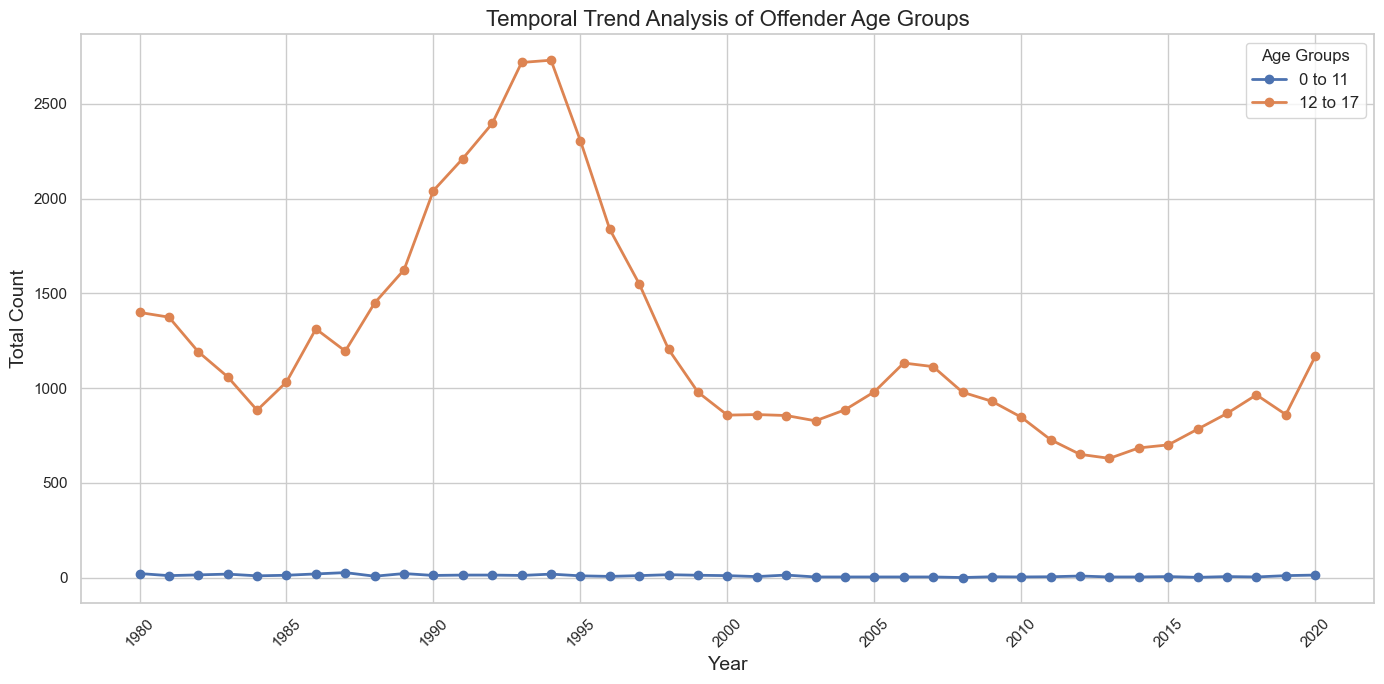

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assume raw_data is your DataFrame with the following columns:
# ['Year', 'State', '0 to 11', '12 to 17', 'Male', 'Female',
#  'Unknown Gender', 'White', 'Black', 'Amer. Indian/Alaskan Native',
#  'Asian/Nat. Hawaiian/Pac Isl', 'Unknown Race', 'Family', 'Acquaintance',
#  'Stranger', 'Unknown', 'Firearm', 'Knife', 'Blunt object', 'Personal',
#  'Other/unknown Weapon', 'One offender involved',
#  'Two or more offenders involved', 'Unknown number of offenders involved']

# For this example, we focus on the continuous columns representing age groups.
continuous_columns = ["0 to 11", "12 to 17"]

# Group the data by "Year" and aggregate the counts by summing the values for each year.
agg_data = raw_data.groupby("Year")[continuous_columns].sum().reset_index()

# Set up Seaborn style for a cleaner appearance.
sns.set(style="whitegrid")

# Create a line plot for each continuous variable over time.
plt.figure(figsize=(14, 7))
for col in continuous_columns:
    plt.plot(agg_data["Year"], agg_data[col], marker='o', linewidth=2, label=col)

plt.title("Temporal Trend Analysis of Offender Age Groups", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Total Count", fontsize=14)
plt.legend(title="Age Groups", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# --------------------------
# Data Preparation
# --------------------------

# Assume raw_data is your DataFrame.
# Ensure "Total Youth" is computed if not already
raw_data['Total Youth'] = raw_data['0 to 11'] + raw_data['12 to 17']

# Define target variables as all columns except 'Year' and 'State'
target_options = [col for col in raw_data.columns if col not in ['Year', 'State']]

# Define model options (using regression models)
model_options = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVR": SVR()
}

# Use historical data (records with Year <= 2020) for training
train_data = raw_data[raw_data['Year'] <= 2020].copy()

# We will use only the "Year" feature to predict each target variable.
X_train = train_data[['Year']]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Prepare future prediction data: Years 2021 to 2060.
future_years = pd.DataFrame({"Year": np.arange(2021, 2061)})
# Scale future years using the same scaler.
X_future_scaled = scaler.transform(future_years[['Year']])

# --------------------------
# Model Training and Future Predictions
# --------------------------
# Dictionary to store predictions.
predictions_dict = {}

# For each model and for each target variable, train on training data and predict on future data.
for model_name, model in model_options.items():
    predictions_dict[model_name] = {}
    for target in target_options:
        y_train = train_data[target]
        # Train a fresh model of the same type.
        mdl = model.__class__()  
        mdl.fit(X_train_scaled, y_train)
        preds = mdl.predict(X_future_scaled)
        # Create a DataFrame of predictions for future years.
        df_pred = future_years.copy()
        df_pred[target] = preds
        predictions_dict[model_name][target] = df_pred

# --------------------------
# Build the Interactive Dashboard with Dash
# --------------------------
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Predicted Trends Dashboard"),
    html.Label("Select Model:"),
    dcc.Dropdown(
        id='model-dropdown',
        options=[{'label': key, 'value': key} for key in model_options.keys()],
        value='Linear Regression'
    ),
    html.Br(),
    html.Label("Select Target Variable:"),
    dcc.Dropdown(
        id='target-dropdown',
        options=[{'label': t, 'value': t} for t in target_options],
        value='Total Youth'
    ),
    dcc.Graph(id='trend-graph')
])

@app.callback(
    Output('trend-graph', 'figure'),
    [Input('model-dropdown', 'value'),
     Input('target-dropdown', 'value')]
)
def update_graph(selected_model, selected_target):
    # Retrieve the prediction DataFrame for the selected model and target variable.
    df = predictions_dict[selected_model][selected_target]
    fig = px.line(
        df,
        x='Year',
        y=selected_target,
        title=f"Predicted Trend for {selected_target} using {selected_model} (2021-2060)",
        markers=True
    )
    fig.update_layout(
        xaxis_title="Year",
        yaxis_title=selected_target,
        template="plotly_white"
    )
    return fig

if __name__ == '__main__':
    app.run(debug=True)

